
Los modelos probabilísticos conducen a expresiones analíticamente intratables, por lo que la matemática, la física y la informática han contribuído en conjunto para obtener métodos numéricos que nos den la posibilidad de automatizar el proceso de inferencia bayesiana.

En esta práctica trabajaremos con PyMC, librería de Python para programación probabilística.

### **Recuerden importar las librerías necesarias**

In [1]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Trabajos\Inferencia 2\venv\Lib\site-packages\preliz\ppls\pymc_io.py:12: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


# **Ejercicio 1:**
Recordemos el ejemplo de la moneda del primer capítulo: vamos a utilizar PyMC para definir un modelo sintético y hacer inferencia, y ArviZ para analizar el _a posterori_.

A continuación generaremos datos sintéticos, en este caso asumiremos que conocemos el valor the $\theta$ que será nuestro `theta_real`, y plantearemos el modelo analíticamente:

## Porque Bernoulli?


Usamos `Bernoulli` en lugar de `Binomial` puramente por **el formato en el que tenés guardados los datos**. El resultado matemático (*posterior*) va a ser exactamente el mismo, solo cambia cómo le pasás la información a PyMC.

1. **Datos desagregados (tiro por tiro):** Usás `Bernoulli` cuando tenés el detalle exacto de cada intento en una lista o array.

```python
# Array con 4 lanzamientos individuales
datos_individuales = [1, 1, 0, 1] 
y = pm.Bernoulli("y", p=θ, observed=datos_individuales)

```

2. **Datos agregados (totales):** Usás `Binomial` cuando ya resumiste la información y solo tenés totales.

```python
# 3 éxitos (caras) en 4 intentos totales
y = pm.Binomial("y", n=4, p=θ, observed=3)

```

Como en tu código generaste un array con 10 resultados separados (los 10 ceros y unos), lo directo es pasárselo a Bernoulli.

Si quisieras usar Binomial sí o sí con esos mismos datos, tendrías que pasarle la suma total y la cantidad de intentos, así:

```python
y = pm.Binomial('y', n=n_experimentos, p=θ, observed=sum(datos))

```

## 

In [2]:
n_experimentos = 10
theta_real = 0.35  # recordar que en una situación real este valor es desconocido
datos = pz.Binomial(n=1, p=theta_real).rvs(size=n_experimentos, random_state=123)
datos

array([1, 0, 0, 0, 0, 1, 1, 0, 1, 1])

Para definir el modelo, pensemos en una distribución beta (con parámetros $\alpha=\beta=1$) como _a priori_ y la distribución de Bernoulli como likelihood:

\begin{align}
\theta &\sim \operatorname{Beta}(\alpha=1, \beta=1)\\
Y &\sim \operatorname{Bin}(n=1, p=\theta)
\end{align}

donde cada elemento del _array_ `datos` que definimos antes será un experimento de Bernoullicon solo dos valores (0 o 1).


**a)** Utilice PyMC para reproducir dicho modelo, definiendo cada distribución con sus parámetros correspondientes.

Guiado:

In [3]:
# with pm.Model() as nuestro_primer_modelo:
#     θ = pm.Beta("θ", alpha=1, beta=1)  # a priori
#     y = pm.Bernoulli("y", p=θ, observed=datos)  # likelihood
#     # y = pm.Binomial('y',n=n_experimentos, p=θ, observed=sum(datos))

In [4]:
with pm.Model() as nuestro_primer_modelo:
    θ = pm.Beta("θ", alpha=1, beta=1)
    y = pm.Bernoulli('y', p=θ, observed = datos)
    


**b)** Utilice `pm.sample()` para obtener muestras de la distribución posterior del modelo definido previamente. Almacene el resultado en un objeto llamado `idata`.



In [5]:
with nuestro_primer_modelo:
    idata = pm.sample(draws=2000, tune=1000,random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


**c)** A partir de las muestras de la distribución *posterior* obtenidas en el inciso anterior, represente gráficamente la *distribución posterior* del parámetro de interés e indique el intervalo de máxima densidad (HDI) del 94%.
 Interprete los resultados obtenidos.

Sugerencia: utilizar la función `plot_forestplot` de ArviZ.

<Axes: title={'center': 'θ'}>

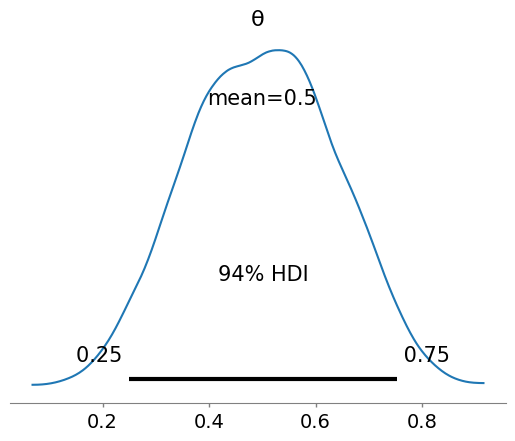

In [6]:
az.plot_posterior(idata)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

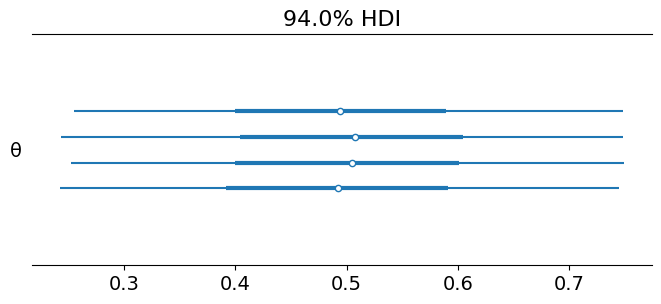

In [7]:
az.plot_forest(idata,figsize=(8, 3))

las 4 cadenas de markov

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

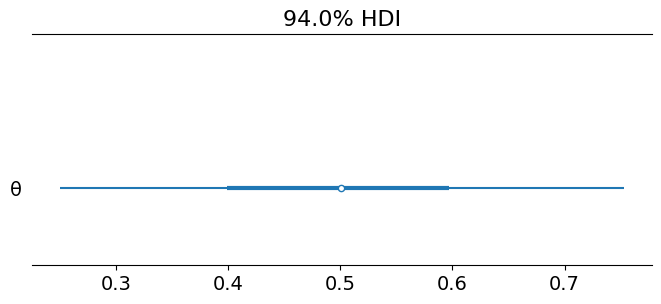

In [8]:
az.plot_forest(idata, var_names=["θ"], hdi_prob=0.94, combined=True, figsize=(8, 3))

 **d)** Reproduzca los resultados vistos en el primer capítulo para el problema de la moneda usando como priors: $Beta(1, 1)$, $Beta(0.5, 0.5)$ y $Beta(20, 20)$.  Utilizar 4 y 150 experimentos y comparar (Incluir alguna representación visual en cada caso).

### Recordatorio del problema de la moneda (Capítulo 1)

En la teoría del primer capítulo vimos el caso de tres personas que intentan estimar el sesgo de una moneda ($\theta$). Cada uno arranca con una creencia previa distinta:

1. **El ignorante:** No sabe nada, asume que cualquier valor es igual de posible. Usa un prior **Beta(1, 1)** (una línea plana).
2. **El desconfiado:** Cree que la moneda está trucada y siempre va a salir cara o siempre ceca, pero no sabe cuál. Usa un prior **Beta(0.5, 0.5)** (forma de U).
3. **El confiado:** Está segurísimo de que la moneda es justa. Usa un prior **Beta(20, 20)** (una campana muy finita centrada en 0.5).

El objetivo de hacer el ejercicio con **4 experimentos** y luego con **150 experimentos** es demostrar que cuando tenés pocos datos (4), el prior (tu prejuicio inicial) domina el resultado final. Pero cuando tenés muchos datos (150), la evidencia aplasta a los prejuicios y los tres *posteriors* terminan convergiendo al valor real ($0.35$).

In [9]:
betas = [(1,1),(0.5,0.5),(20,20)]
tamaños_n = [4,150]
i_datas = []

for n in tamaños_n:
    datos = pz.Binomial(n=1, p=theta_real).rvs(size=n, random_state=123)

    for alpha,beta in betas:
        with pm.Model() as modelo_temp:
            #prior
            theta = pm.Beta("theta", alpha=alpha, beta=beta )
            #likelihood
            y = pm.Bernoulli("y", p=theta, observed= datos )
            #posterior
            idata_temp = pm.sample(draws=1000, tune=1000, random_seed=42, progressbar=False)
            i_datas.append(idata_temp.copy())

print(len(i_datas))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 

6


In [10]:
i_datas_4 = i_datas[:3]
i_datas_150 = i_datas[3:]

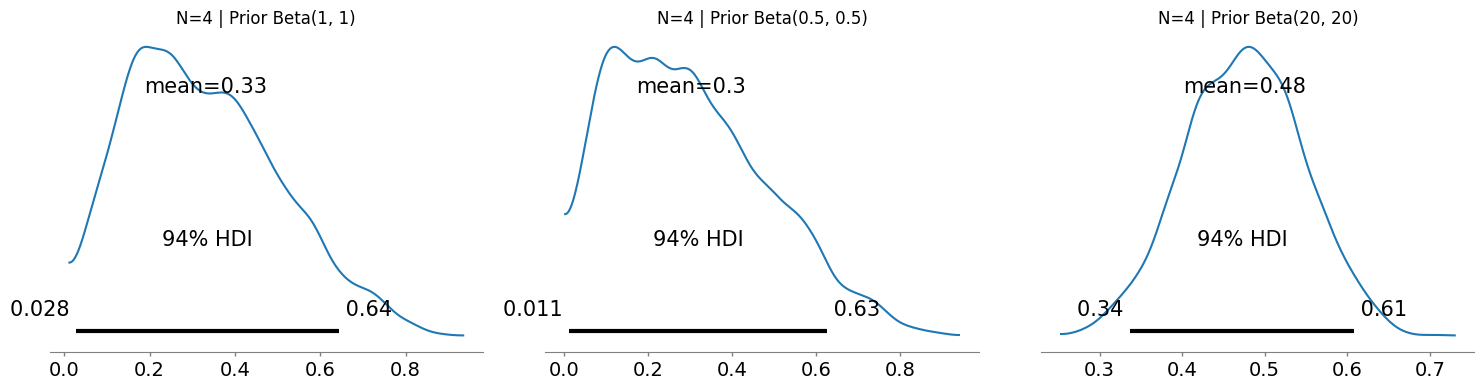

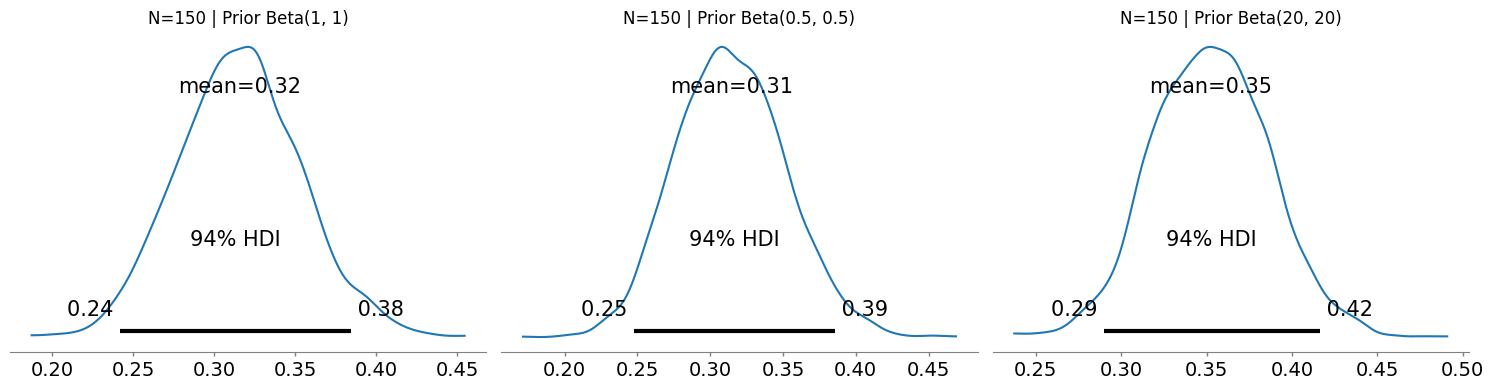

In [11]:
# Definimos los títulos correspondientes
priors_nombres = ["Beta(1, 1)", "Beta(0.5, 0.5)", "Beta(20, 20)"]

# --- Plot N = 4 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, idata in enumerate(i_datas_4):
    az.plot_posterior(idata, ax=axes[idx], hdi_prob=0.94)
    axes[idx].set_title(f"N=4 | Prior {priors_nombres[idx]}")

plt.tight_layout()
plt.show()

# --- Plot N = 150 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, idata in enumerate(i_datas_150):
    az.plot_posterior(idata, ax=axes[idx], hdi_prob=0.94)
    axes[idx].set_title(f"N=150 | Prior {priors_nombres[idx]}")

plt.tight_layout()
plt.show()

## **Ejercicio 2:**

Para cada una de las siguientes situaciones, indique qué distribución de probabilidad utilizaría para modelar los datos y justifique brevemente su elección.

**a)** Cantidad de clientes que ingresan a un supermercado en una hora.

**b)** Tiempo de duración de una llamada telefónica.

**c)** Resultado de un examen (aprobado/desaprobado).

**d)** Número de productos defectuosos en una muestra de 20 artículos.



* **a) Cantidad de clientes que ingresan a un supermercado en una hora.**

    - **Distribución:** **Poisson**.
    - **Justificación:** Modela la cantidad de eventos discretos que ocurren de forma independiente en un intervalo de tiempo continuo a una tasa constante.

* **b) Tiempo de duración de una llamada telefónica.**

    - **Distribución:** **Exponencial** (o **Gamma** / **Log-Normal**).
    - **Justificación:** Es el estándar para modelar el tiempo transcurrido entre eventos o la duración de procesos continuos que son estrictamente positivos y sesgados hacia la derecha.

* **c) Resultado de un examen (aprobado/desaprobado).**

    - **Distribución:** **Bernoulli** (o Binomial con $N=1$).
    - **Justificación:** Modela un experimento aleatorio con exactamente dos resultados posibles mutuamente excluyentes (éxito/fracaso, 1/0).

* **d) Número de productos defectuosos en una muestra de 20 artículos.**

    - **Distribución:** **Binomial**.
    - **Justificación:** Modela el número total de éxitos en un número fijo $N=20$ de ensayos independientes de Bernoulli, asumiendo que la probabilidad de defecto es constante para cada artículo.

## **Ejercicio 3:**

Pensando como modeladores

Imagine que es un Modelador Bayesiano que trabaja en proyectos diversos, y considere cada una de las siguientes afirmaciones indicando si es verdadera o falsa. Justifique en todos los casos.

**a)** Si se dispone de una gran cantidad de datos, la elección de la distribución a priori deja de tener influencia sobre la distribución posterior.

**b)** Toda variable observada debe modelarse mediante una distribución Normal.

**c)** En un modelo bayesiano, los parámetros desconocidos se representan mediante variables aleatorias.

**d)** Dos modelos diferentes pueden utilizar la misma distribución de verosimilitud pero distintas distribuciones a priori.

* **a)**  
Falso, depende de que tanta influencia tenga la prior. No tiene la misma influencia como prior una beta(1,1) que una beta(1000,1000) frente a una likelihood con 20 experimentos.

* **b)** 
Falso, cada variable observada debe modelarse segun sus caracteristicas. Binomial para numero de exitos de tantos experimentos, Poisson para eventos que transcurren en un tiempo, etc.

* **c)**  
Verdadero, en un modelo bayesiano no se realiza la estimacion de un valor como en el frecuentista, sino que le asignamos una distribucion segun la incertidumbre que tenemos sobre ese parametro.

* **d)**   
Verdadero, cada verosimilitud no tiene una prior unica asignada, son a eleccion y decision de la persona que realiza el modelo. Hasta se pueden llegar a probar varias priors, para ver cual se ajusta mejor al objetivo.


## **Ejercicio 4:**

Se desea estimar la probabilidad de que un usuario haga clic en un anuncio publicitario. Durante una campaña se mostraron 100 anuncios y se registraron 14 clics.

**a)** Proponga un modelo bayesiano para este problema.

**b)** Obtenga la distribución posterior.

**c)** Estime la probabilidad de que la tasa de clics sea superior al 15%.

a)

No cuento con informacion previa asi que para la prior:

theta ~ beta(1,1)

Likelihood, como los datos son los exitos de un numero de intentos binomial

Y|theta ~ Binomial(n=100, theta)

In [17]:
#b)
n = 100
y = 14

with pm.Model() as modelo_anuncios:
    theta = pm.Beta("theta", alpha=1, beta = 1)
    likelihood = pm.Binomial("likelihood", n=n, p=theta, observed =y)

    idata = pm.sample(draws=2000, tune = 1000, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


<Axes: title={'center': 'theta'}>

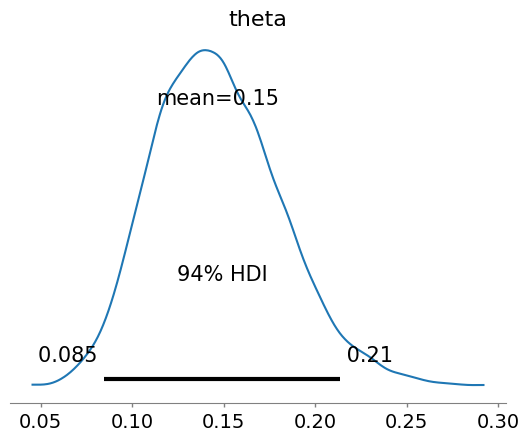

In [18]:
az.plot_posterior(idata)

<Axes: title={'center': 'theta'}>

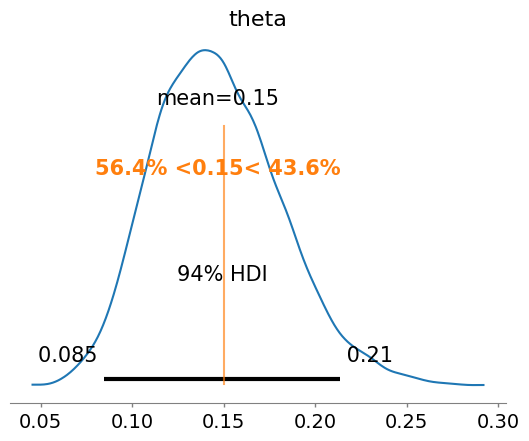

In [19]:
az.plot_posterior(idata, ref_val=0.15)

In [33]:
# c) Estime la probabilidad de que la tasa de clics sea superior al 15%.

# 1. Calculamos la proporción matemática exacta
prob_exacta = (idata.posterior["theta"] > 0.15).mean().item()

# 2. Imprimimos el resultado numérico
print(f"La probabilidad exacta es: {prob_exacta:.3f}")

La probabilidad exacta es: 0.436


###########

<font color="teal"> **NOTA PARA LOS ESTUDIANTES:**

En PyMC, los modelos probabilísticos se construyen dentro de un bloque with, que indica que todas las variables definidas en su interior forman parte del mismo modelo bayesiano. Para incorporar una distribución de probabilidad basta con agregar una línea de código utilizando la distribución correspondiente.

Las distribuciones pueden desempeñar dos roles distintos:

*Variables no observadas (priors):* representan parámetros desconocidos del modelo.

*Variables observadas (likelihoods):* representan los datos disponibles y se especifican mediante el argumento observed.

Una vez definido el modelo, PyMC utiliza algoritmos de muestreo (MCMC) para generar muestras de la distribución posterior. Si bien lo iremos estudiando durante el curso, es importante destacar que si el procedimiento converge adecuadamente, estas muestras constituyen una aproximación de la distribución posterior y permiten estudiar qué valores del parámetro son más compatibles con el modelo y los datos observados.

Por otro lado, ArviZ es una biblioteca complementaria que facilita la exploración y el diagnóstico de los resultados obtenidos con PyMC (y también con otras herramientas de inferencia bayesiana).

Entre sus utilidades se encuentran los resúmenes estadísticos, los gráficos de la distribución posterior y el cálculo de intervalos HDI (Highest Density Interval). Una estrategia frecuente para interpretar resultados consiste en comparar el intervalo HDI con una **ROPE (Region of Practical Equivalence)**:

- Si el HDI queda completamente dentro de la ROPE, el efecto puede considerarse prácticamente equivalente a cero.

- Si el HDI queda completamente fuera de la ROPE, existe evidencia de un efecto relevante.

- Si ambos intervalos se superponen parcialmente, la conclusión es menos clara y puede requerirse más información.